# 01. Neural Network Regression with Tensorflow

Imagine your brain: It has billions of tiny cells called neurons that connect and send signals to each other. They "talk" to figure out things like "Is that a smile?" or "Should I run from that shadow?"

A neural network is a computer version of that. It's like a bunch of fake brain cells (math-based "neurons") wired together in a web. Here's how it works in simple steps:

1. **Input (What You Feed It):** You give it data, like a photo of a cat. Each part of the photo (colors, shapes) goes into the first layer of neurons.

2. **Layers of Neurons (The Thinking Part):**

    - The network has **layers** stacked like a sandwich:
    
        - **Input Layer:** Grabs the raw data (e.g., pixel by pixel of the photo).
        - **Hidden Layers (the "deep" part):** These are the magic middle layers. Each neuron here looks at a bit of info, does simple math (like adding weights or biases—think of it as "importance scores"), and passes a signal to the next layer. They learn patterns, like "whiskers + fur = probably a cat."
        - **Output Layer:** Spits out the answer, like "90% sure it's a cat."
    
    - More layers = "deeper" network = better at spotting complex stuff (that's deep learning!).

3. **Learning (How It Gets Smart):** At first, it's dumb and guesses wrong. You tell it "Nope, that's a dog!" and it tweaks its connections (adjusts those "weights") to do better next time. Repeat this with tons of examples, and it learns—like practicing a skill until you're a pro.

**Resources:** 

- [MIT 6.S191 Introduction to Deep Learning](https://www.youtube.com/playlist?list=PLtBw6njQRU-rwp5__7C0oIVt26ZgjG9NI)

### Typical architecture of a regresison neural network

| Hyperparameter | Typical value |
| -------------- | ------------- |
| Input layer shape | Same shape as number of features (e.g. 3 for # bedrooms, # bathrooms, # car spaces in housing price prediction) |
| Hidden layer(s) | Problem specific, minimum = 1, maximum = unlimited |
| Neurons per hidden layer | Problem specific, generally 10 to 100 |
| Output layer shape | Same shape as desired prediction shape (e.g. 1 for house price) |
| Hidden activation | Usually [ReLU](https://www.kaggle.com/code/dansbecker/rectified-linear-units-relu-in-deep-learning) (rectified linear unit) |
| Output activation | None, ReLU, logistic/tanh |
| Loss function | [MSE](https://en.wikipedia.org/wiki/Mean_squared_error) (mean square error) or [MAE](https://en.wikipedia.org/wiki/Mean_absolute_error) (mean absolute error)/Huber (combination of MAE/MSE) if outliers |
| Optimizer | [SGD](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/SGD) (stochastic gradient descent), [Adam](https://www.tensorflow.org/api_docs/python/tf/keras/optimizers/Adam) |

*Table 1: Typical architecture of a regression network. Source: Adapted from page 293 of [Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow Book by Aurélien Géron](https://www.oreilly.com/library/view/hands-on-machine-learning/9781492032632)*

> **Note:** A **hyperparameter** in machine learning is something a data analyst or developer can set themselves, where as a **parameter** usually describes something a model learns on its own (a value not explicitly set by an analyst).

### What is a regression?

**Regression** is a type of problem in machine learning and statistics where we try to predict a number (a continuous value) based on input data.

**Key idea:**

You're trying to find a relationship between the input(s) (like size of a house) and the output (like its price), so that when you get new input data, you can predict the output.

**Real-life examples of regression:**

- Predicting the price of a house based on its size, location, and number of rooms.
- Estimating temperature tomorrow based on weather data.
- Predicting a student’s score based on hours studied.
- Forecasting sales based on advertising budget and past trends.

In [23]:
import tensorflow as tf

In [2]:
tf.__version__

'2.19.1'

### Create Data to View and Fit

In [3]:
import numpy as np
import matplotlib.pyplot as plt

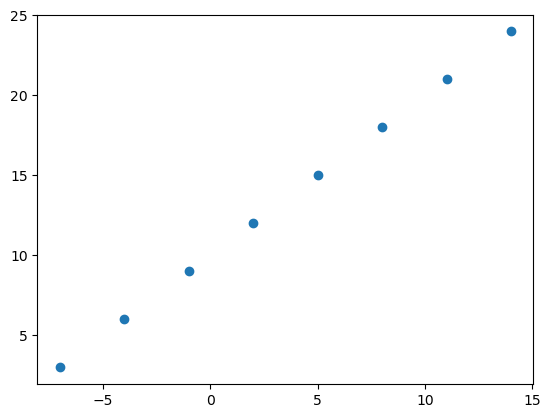

In [4]:
# create features
X = np.array([-7,-4,-1,2,5,8,11,14])

# create labels
y = np.array([3,6,9,12,15,18,21,24])

# visualize
plt.scatter(X, y)

### Input and Output Shapes

In [24]:
# create a demo tensor for our housing price prediction problem
house_info = tf.constant(["bedroom", "bathroom", "garage"])
house_price = tf.constant([930700])
house_info, house_price

(<tf.Tensor: shape=(3,), dtype=string, numpy=array([b'bedroom', b'bathroom', b'garage'], dtype=object)>,
 <tf.Tensor: shape=(1,), dtype=int32, numpy=array([930700], dtype=int32)>)

In [6]:
# turn our numpy arrays into tensors
X = tf.constant(X)
y = tf.constant(y)
X, y

(<tf.Tensor: shape=(8,), dtype=int64, numpy=array([-7, -4, -1,  2,  5,  8, 11, 14])>,
 <tf.Tensor: shape=(8,), dtype=int64, numpy=array([ 3,  6,  9, 12, 15, 18, 21, 24])>)

### Steps in Modelling with Tensorflow

In [7]:
tf.random.set_seed(42)

# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(50, activation=None),
    tf.keras.layers.Dense(1)
])

# compile the model
model.compile(loss=tf.keras.losses.mae,
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics=["mae"])

# fit the model
model.fit(tf.expand_dims(X, axis=-1), y, epochs=100, verbose=0)
print("Model Fitted!")

Model Fitted!


In [8]:
# make a prediction
y_preds = model.predict(tf.constant([17.0]))
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


array([[26.58582]], dtype=float32)

### Imporving the Model

Improving a TensorFlow model involves optimizing its architecture, training process, and data handling to enhance performance, reduce overfitting, and increase efficiency. Below is a list of key methods with short descriptions:

1. **Hyperparameter Tuning**


   Adjust learning rate, batch size, or number of epochs using tools like Keras Tuner to find optimal settings for better convergence and performance.

3. **Data Augmentation**

    Apply transformations (e.g., rotation, flipping for images) to increase dataset diversity, reducing overfitting and improving generalization.

3. **Regularization**

    Use techniques like L2 regularization or Dropout (e.g., tf.keras.layers.Dropout(0.2)) to prevent overfitting by penalizing large weights or randomly dropping neurons.

4. **Batch Normalization**

    Add tf.keras.layers.BatchNormalization to normalize layer inputs, stabilizing and accelerating training while reducing sensitivity to initialization.

5. **Advanced Optimizers**

    Experiment with optimizers like AdamW, RMSprop, or SGD with momentum instead of default Adam for better convergence on specific tasks.

6. **Model Architecture Optimization**

    Use deeper or wider networks, or task-specific layers (e.g., Conv2D for images, LSTM for sequences) to better capture data patterns.

7. **Transfer Learning**

    Use pre-trained models (e.g., tf.keras.applications.ResNet50) and fine-tune on your dataset to leverage learned features, especially with limited data.

8. **Early Stopping**

    Implement tf.keras.callbacks.EarlyStopping to halt training when validation performance stops improving, preventing overfitting.

9. **Learning Rate Scheduling**

    Use tf.keras.callbacks.ReduceLROnPlateau or custom schedules to adjust the learning rate dynamically, improving convergence.

10. **Increase Dataset Quality/Size**

    Clean data, remove noise, or gather more samples to provide the model with better and more diverse training examples.

11. **Feature Engineering**

    Create or select more relevant features (e.g., scaling, encoding) to improve the model’s ability to learn meaningful patterns.

12. **Ensemble Methods**

    Combine predictions from multiple models (e.g., averaging or stacking) to boost accuracy and robustness.

13. **Mixed Precision Training**

    Enable mixed precision with tf.keras.mixed_precision to speed up training and reduce memory usage while maintaining accuracy.

14. **Cross-Validation**

    Use k-fold cross-validation to evaluate model performance more reliably and reduce variance in performance estimates.

15. **Monitor with TensorBoard**

    Visualize training metrics (e.g., loss, accuracy) using tf.keras.callbacks.TensorBoard to diagnose issues and guide improvements.

### Evaluating a Model

TensorFlow model involves assessing its performance using various metrics and techniques. Below is a list of common evaluation methods with brief descriptions:

1. **Accuracy**

    Measures the proportion of correct predictions for classification tasks.

2. **Loss Function**

    Quantifies the difference between predicted and actual values (e.g., cross-entropy for classification, MSE for regression).

3. **Precision**

    Ratio of true positive predictions to total predicted positives, useful for imbalanced datasets.

4. **Recall**

    Ratio of true positive predictions to total actual positives, emphasizing missed positives.

5. **F1 Score**

    Harmonic mean of precision and recall, balancing both for classification tasks.

6. **Confusion Matrix**

    Table showing true vs. predicted labels to analyze classification errors.

7. **ROC-AUC**

    Area under the Receiver Operating Characteristic curve, measuring classification performance across thresholds.

8. **Mean Absolute Error (MAE)**

    Average absolute difference between predicted and actual values for regression tasks.

9. **Mean Squared Error (MSE)**

    Average squared difference between predicted and actual values, penalizing larger errors.

10. **R² Score**

    Measures the proportion of variance in the dependent variable explained by the regression model.

11. **Cross-Validation**

    Splits data into k-folds to evaluate model performance across multiple subsets.

12. **Validation Set Performance**

    Assesses model performance on a separate validation set during training to monitor generalization.

13. **Test Set Evaluation**

    Final evaluation on a held-out test set to estimate real-world performance.

14. **Learning Curves**

    Plots training and validation metrics over epochs to diagnose underfitting or overfitting.

15. **Prediction Visualization**

    Visualizes predictions (e.g., scatter plots, heatmaps) to qualitatively assess model behavior.

In [9]:
# generate random data
X = tf.range(-100, 100, 4)
y = X + 10

In [10]:
X, y

(<tf.Tensor: shape=(50,), dtype=int32, numpy=
 array([-100,  -96,  -92,  -88,  -84,  -80,  -76,  -72,  -68,  -64,  -60,
         -56,  -52,  -48,  -44,  -40,  -36,  -32,  -28,  -24,  -20,  -16,
         -12,   -8,   -4,    0,    4,    8,   12,   16,   20,   24,   28,
          32,   36,   40,   44,   48,   52,   56,   60,   64,   68,   72,
          76,   80,   84,   88,   92,   96], dtype=int32)>,
 <tf.Tensor: shape=(50,), dtype=int32, numpy=
 array([-90, -86, -82, -78, -74, -70, -66, -62, -58, -54, -50, -46, -42,
        -38, -34, -30, -26, -22, -18, -14, -10,  -6,  -2,   2,   6,  10,
         14,  18,  22,  26,  30,  34,  38,  42,  46,  50,  54,  58,  62,
         66,  70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

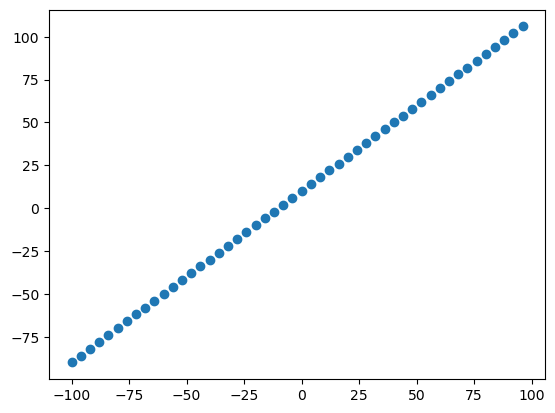

In [11]:
# visualize the data
plt.scatter(X, y)

### Splitting Dataset

1. **Training Dataset**

    - Purpose: Used to train the model.
    - What happens: The model learns patterns and adjusts its weights using this data.

2. **Validation Dataset**

    - Purpose: Used to tune the model during training.
    - What happens: Helps monitor the model's performance on unseen data while training (e.g., for early stopping, hyperparameter tuning).

3. **Testing Dataset**

    - Purpose: Used to evaluate the final model's performance.
    - What happens: The model's accuracy/generalization is checked after training to ensure it works well on completely unseen data.

In [12]:
X_train = X[:40] # 1st 40 are training samples
y_train = y[:40]

X_test = X[40:] # last 10 are testing samples
y_test = y[40:]

len(X_train), len(y_test), len(X_test), len(y_train)

(40, 10, 10, 40)

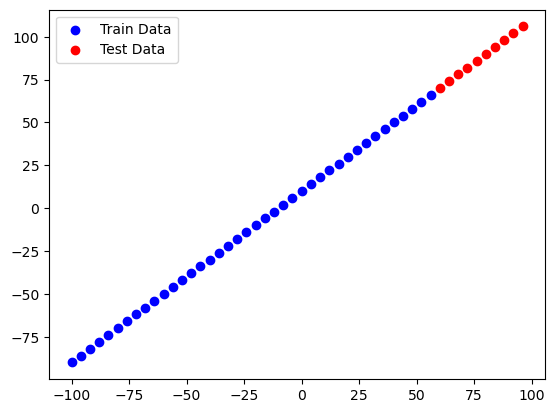

In [13]:
# visualized the data
plt.scatter(X_train, y_train, c="b", label="Train Data")
plt.scatter(X_test, y_test, c="red", label="Test Data")
plt.legend()

In [14]:
tf.random.set_seed(42)

# create a model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(10, name="input_layer"),
    tf.keras.layers.Dense(1, name="output_layer")
], name="model_1")

# compile the model
model.compile(loss=tf.keras.losses.mae,
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
             metrics=["mae"])

# fit the model
model.fit(tf.expand_dims(X_train, axis=-1), y_train, epochs=300, verbose=0)
print("Model Fitted!")

Model Fitted!


In [15]:
y_preds = model.predict(X_test)
y_preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


array([[ 69.564384],
       [ 73.53686 ],
       [ 77.50932 ],
       [ 81.4818  ],
       [ 85.45426 ],
       [ 89.426735],
       [ 93.39921 ],
       [ 97.371666],
       [101.34414 ],
       [105.316605]], dtype=float32)

In [16]:
model.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (Dense)             │ (None, 10)             │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 95 (384.00 B)

 Trainable params: 31 (124.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 64 (260.00 B)

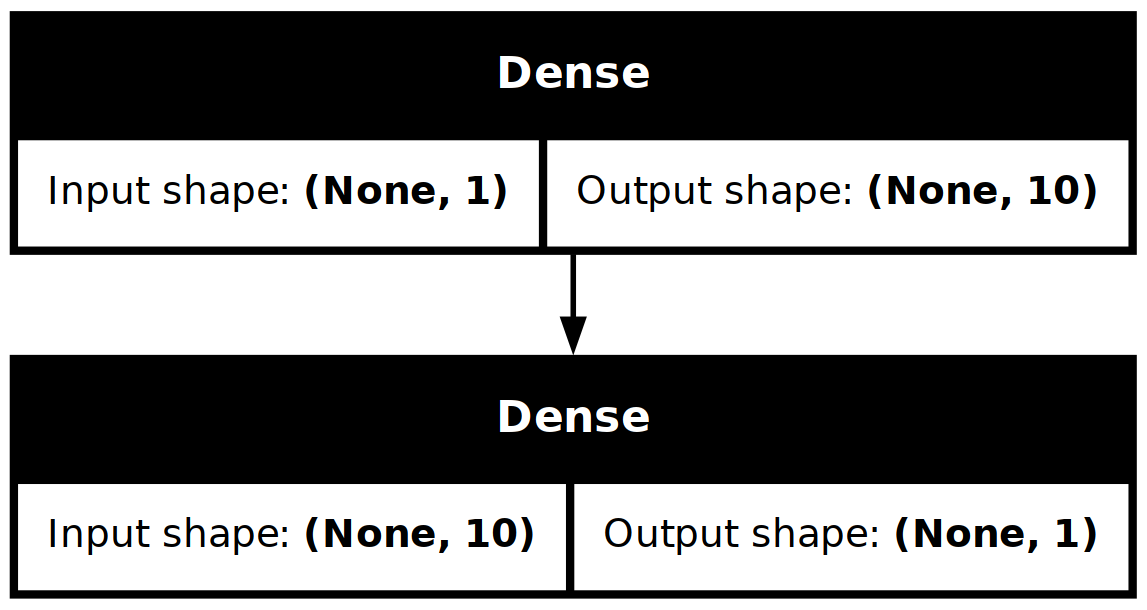

In [17]:
from tensorflow.keras.utils import plot_model

plot_model(model=model, show_shapes=True)

### Neural Network Weights and Biases

1. **Weights**

    Control the strength of the input data's influence.

    - Purpose: Weights determine the importance of the input features.
    
    - Role: When data flows through the network, each input is multiplied by a weight, which adjusts how much influence that input has on the output.
    
    - How it works: During training, the model learns the optimal weights that help make better predictions.
    
    - Example: In a neural network, the input might be "height" and "weight" to predict "age". Each of these inputs will have a weight that tells the model how important they are in predicting age.
  
    > output = (input_1 * weight_1) + (input_2 * weight_2)

2. **Bias**

    Shifts the output, helping the model make predictions even when inputs are zero or have low influence.

    - Purpose: Bias allows the model to adjust the output independently of the input values.
    
    - Role: It acts like an "offset" that helps the model make predictions even when the input is zero (or close to zero).
    
    - How it works: The bias is added to the weighted sum of inputs before passing it through the activation function.
    
    - Example: Imagine the input to the model is zero (e.g., no information), the bias helps push the output away from zero so that the model doesn't always output zero.
  
    > output = (input_1 * weight_1) + (input_2 * weight_2) + bias

### Visualizing our Model's Predictions

In [18]:
y_preds, y_test

(array([[ 69.564384],
        [ 73.53686 ],
        [ 77.50932 ],
        [ 81.4818  ],
        [ 85.45426 ],
        [ 89.426735],
        [ 93.39921 ],
        [ 97.371666],
        [101.34414 ],
        [105.316605]], dtype=float32),
 <tf.Tensor: shape=(10,), dtype=int32, numpy=array([ 70,  74,  78,  82,  86,  90,  94,  98, 102, 106], dtype=int32)>)

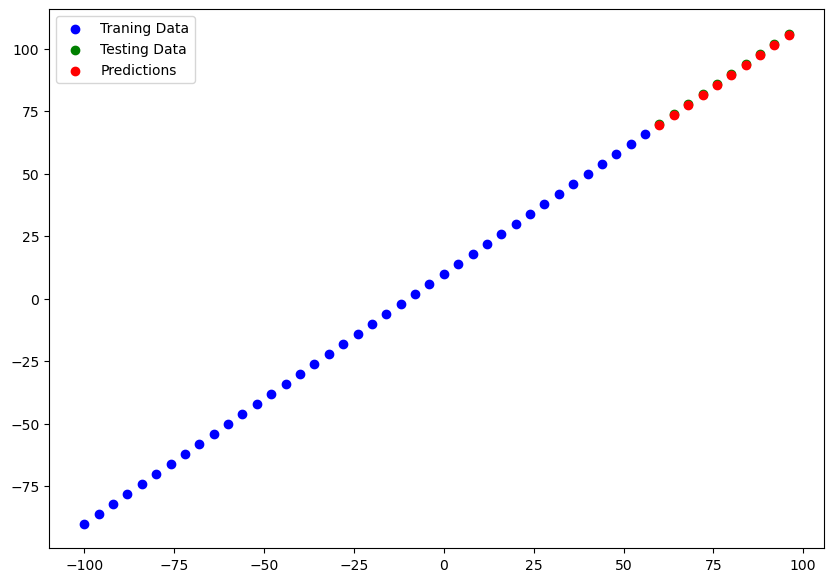

In [19]:
def plot_predictions(train_data=X_train,
                    train_labels=y_train,
                    test_data=X_test,
                    test_labels=y_test,
                    predictions=y_preds):
    """
    Plots training data, test data and compares predictions to ground truth labels
    """

    plt.figure(figsize=(10, 7))
    # plot training data
    plt.scatter(train_data, train_labels, c="b", label="Traning Data")
    # plot testing data
    plt.scatter(test_data, test_labels, c="g", label="Testing Data")
    # plot models predictions in red
    plt.scatter(test_data, predictions, c="r", label="Predictions")
    plt.legend()

plot_predictions()

### Evaluating our Model's Predictions with Regression Evalution Metrics

1. **Mean Squared Error (MSE):**

    - Measures the average of the squared differences between predicted and actual values.
    - Formula: $$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$
    - TensorFlow: `tf.keras.metrics.MeanSquaredError()`
    - Use: Penalizes larger errors more heavily; widely used for regression.

2. **Mean Absolute Error (MAE)**

    - Measures the average of the absolute differences between predicted and actual values.
    - Formula: $$
MAE = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i|
$$
    - TensorFlow: `tf.keras.metrics.MeanAbsoluteError()`
    - Use: More robust to outliers than MSE.

3. **Root Mean Squared Error (RMSE)**

    - The square root of MSE, providing error in the same units as the target variable.
    - Formula: $$
RMSE = \sqrt{MSE}
$$
    - TensorFlow: `tf.keras.metrics.RootMeanSquaredError()`
    - Use: Interpretable in the original scale of the data.

4. **Mean Absolute Percentage Error (MAPE)**

    - Measures the average percentage difference between predicted and actual values.
    - Formula: $$
MAPE = \frac{1}{n} \sum_{i=1}^{n} \left| \frac{y_i - \hat{y}_i}{y_i} \right| \times 100
$$
    - TensorFlow: `tf.keras.metrics.MeanAbsolutePercentageError()`
    - Use: Useful when you want errors relative to the magnitude of the actual values (avoid when `y_true` is close to zero).

5. **Mean Squared Logarithmic Error (MSLE)**

    - Measures the average of the squared logarithmic differences between predicted and actual values.
    - Formula: $$
MSLE = \frac{1}{n} \sum_{i=1}^{n} (\log(y_i + 1) - \log(\hat{y}_i + 1))^2
$$
    - TensorFlow: `tf.keras.metrics.MeanSquaredLogarithmicError()`
    - Use: Suitable for targets with exponential growth or wide-ranging values.

6. **R² Score (Coefficient of Determination)**

    - Measures the proportion of variance in the dependent variable explained by the model.
    - Formula: $$
R^2 = 1 - \frac{\sum_{i=1}^{n} (y_i - \hat{y}_i)^2}{\sum_{i=1}^{n} (y_i - \bar{y})^2}
$$
    - TensorFlow: Not directly available in `tf.keras.metrics`, but can be implemented using `tf.keras.metrics.Mean` and custom logic.
    - Use: Indicates how well the model fits the data (higher is better, max 1.0).

7. **Huber Loss**

    - A loss function that is less sensitive to outliers than MSE, combining MSE and MAE properties.
    - Formula: Uses a threshold `δ` to switch between quadratic (for small errors) and linear (for large errors) loss. $$
L_\delta (y, \hat{y}) = \begin{cases} 
\frac{1}{2}(y - \hat{y})^2 & \text{for} \, |y - \hat{y}| \leq \delta \\
\delta |y - \hat{y}| - \frac{1}{2}\delta^2 & \text{otherwise}
\end{cases}
$$
    - TensorFlow: Not a standard metric in `tf.keras.metrics`, but available as a loss function (`tf.keras.losses.Huber()`). Can be used as a metric with custom implementation.
    - Use: Balances robustness and sensitivity to errors.

8. **Log-Cosh Loss**

    - Measures the logarithm of the hyperbolic cosine of the prediction error.
    - Formula: $$
\rho = 1 - \frac{6 \sum_{i=1}^{n} d_i^2}{n(n^2 - 1)}
$$
    - TensorFlow: Not a standard metric, but can be implemented as a custom metric.
    - Use: Smooth approximation of Huber loss, less sensitive to outliers.

In [20]:
# evaluate the model on the test sets
model.evaluate(X_test, y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.5595 - mae: 0.5595


[0.5595024228096008, 0.5595024228096008]

In [21]:
# calculate the mae
tf.keras.metrics.mae(y_test, tf.squeeze(y_preds))

<tf.Tensor: shape=(), dtype=float32, numpy=0.5595024228096008>

In [22]:
# calculate the mse
tf.keras.metrics.mse(y_test, tf.squeeze(y_preds))

<tf.Tensor: shape=(), dtype=float32, numpy=0.31929609179496765>

### Improving and Experimenting to Improve Model

- **Get more or better data:** Train on larger datasets to help the model learn patterns better. Use TensorFlow's `tf.data` API to load and preprocess data efficiently, or apply data augmentation (e.g., flipping or rotating images) `with tf.keras.layers.RandomFlip()` to create variations without collecting new data.
- **Tune hyperparameters:** Experiment with settings like learning rate, batch size, or number of layers. Use TensorFlow's `tf.keras.callbacks.EarlyStopping` to stop training when the model stops improving, or try grid search with libraries like Keras Tuner to find the best combo automatically.
- **Add regularization to prevent overfitting:** Stop the model from memorizing data instead of learning. In TensorFlow, add dropout layers with `tf.keras.layers.Dropout(0.5)` (which randomly ignores 50% of neurons during training) or use L2 regularization in the optimizer like `tf.keras.optimizers.Adam(learning_rate=0.001, weight_decay=0.0001)`.
- **Use a better optimizer or learning schedule:** Switch from basic Adam to something like RMSprop for faster convergence. In TensorFlow, set a learning rate schedule with `tf.keras.callbacks.ReduceLROnPlateau` to automatically lower the rate when accuracy plateaus.
- **Ensemble multiple models:** Combine predictions from several models for more reliable results. Train a few models with TensorFlow and average their outputs using simple NumPy or TensorFlow ops like `tf.reduce_mean()`.
- **Fine-tune a pre-trained model:** Start with a model trained on a huge dataset (like ImageNet) and tweak it for your task. Use TensorFlow Hub or `tf.keras.applications` to load models like ResNet, then freeze early layers with `layer.trainable = False` and train only the top ones.
- **Monitor and visualize training:** Track metrics like loss and accuracy in real-time. Use TensorFlow's `tf.keras.callbacks.TensorBoard` to log data and view interactive charts in TensorBoard, helping you spot issues early.

### Comparing the Results of Model Expirements

- **Direct metric comparison:** Train both models, then run `model_a.evaluate(test_data)` and `model_b.evaluate(test_data)` to get metrics like accuracy, loss, precision, or recall. Print or tabulate them side-by-side (e.g., Model A: 92% accuracy; Model B: 88%) to see which wins overall or per metric.
- **Plot training/validation curves:** Use `history_a = model_a.fit(...)` and `history_b = model_b.fit(...)`, then plot loss/accuracy over epochs with Matplotlib: `plt.plot(history_a.history['loss'], label='Model A')` and similarly for Model B. This shows which converges faster or overfits less.
- **Compare predictions visually:** Generate predictions with `preds_a = model_a.predict(test_data)` and `preds_b = model_b.predict(test_data)`. Plot them against true labels (e.g., scatter plot of predicted vs. actual) or compute differences with `tf.math.abs(preds_a - preds_b)` to highlight where they disagree.
- **Statistical significance test:** Compute metrics on multiple runs or cross-validation folds, then use a t-test (via SciPy: `scipy.stats.ttest_ind(scores_a, scores_b)`) on the results. This checks if one model's better performance (e.g., higher accuracy) is statistically significant, not just random.
- **ROC/AUC curve comparison:** For classification, use `tf.keras.metrics.AUC()` or scikit-learn's `roc_curve` on predictions. Plot both ROC curves on one graph (`plt.plot(fpr_a, tpr_a, label='Model A')`) and compare AUC scores—the higher one indicates better discrimination.
- **Confusion matrix side-by-side:** Get predictions, then create matrices with `tf.math.confusion_matrix(true_labels, preds_a)` and for Model B. Plot them as heatmaps next to each other (using `seaborn.heatmap`) to compare error types, like which model misclassifies more in certain categories.
- **Inference speed and efficiency:** Time predictions with `start = time.time(); model_a.predict(test_data); time_a = time.time() - start` (and same for Model B). Compare times, or use `tf.profiler` to log FLOPs/memory—great for picking the faster one for real-world use.

### Saving Model

- **SavedModel format (recommended for production):** Saves the entire model (architecture, weights, and config) in a portable directory. Use `model.save('my_model')` to save, and `tf.saved_model.load('my_model')` to load. It's great for serving with TensorFlow Serving or exporting to other frameworks.
- **HDF5 format (.h5):** Stores the model architecture and weights in a single file. Call `model.save('my_model.h5')` to save, and `tf.keras.models.load_model('my_model.h5')` to load. Ideal for quick saves during experiments.
- **Weights only:** Save just the trained parameters (not the full architecture) to reuse in another model. Use `model.save_weights('my_weights.h5')` to save, and `model.load_weights('my_weights.h5')` to load. This keeps files small but requires rebuilding the model structure first.
- **TensorFlow Lite (.tflite) for mobile/edge devices:** Convert and save a lightweight version optimized for inference on phones or IoT. Run `converter = tf.lite.TFLiteConverter.from_keras_model(model); tflite_model = converter.convert(); with open('my_model.tflite', 'wb') as f: f.write(tflite_model)`. Load with the TFLite interpreter.
- ONNX format for cross-framework use: Export to the Open Neural Network Exchange standard for compatibility with other tools like PyTorch. Use `tf2onnx.convert.from_keras(model, output_path='my_model.onnx')` (requires the tf2onnx package). Load in ONNX Runtime or similar.
- **Save Model with Checkpoints (for Training):** If you want to save checkpoints during training (useful for resuming training or fine-tuning), you can use ModelCheckpoint during training. This saves the model at regular intervals based on the validation performance.

    ```Python
    from tensorflow.keras.callbacks import ModelCheckpoint
    
    checkpoint = ModelCheckpoint('model_checkpoint.h5', save_best_only=True, monitor='val_loss', mode='min')
    
    model.fit(train_data, train_labels, validation_data=(val_data, val_labels), epochs=10, callbacks=[checkpoint])
    ```
- **Save the Model with a Custom Callback (for Advanced Scenarios):** You might want to save the model at specific points during training based on custom logic (e.g., based on loss or accuracy at specific intervals).

    ```Python
    class CustomSaveCallback(tf.keras.callbacks.Callback):
        def on_epoch_end(self, epoch, logs=None):
            if logs.get('val_loss') < 0.2:  # Custom condition
                self.model.save(f"custom_model_{epoch}.h5")
    
    # Use the custom callback in training
    custom_callback = CustomSaveCallback()
    model.fit(train_data, train_labels, epochs=10, callbacks=[custom_callback])
    ```

### Example of Larger Data

In [79]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import make_column_transformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [26]:
insurance = pd.read_csv("../../data/insurance.csv")

In [27]:
insurance.head(3)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.90,0,yes,southwest,16884.9240
1,18,male,33.77,1,no,southeast,1725.5523
2,28,male,33.00,3,no,southeast,4449.4620


In [80]:
# one-hot encoding
# insurance_on_hot = pd.get_dummies(insurance)

### Types of One-Hot Enconding

One-hot encoding is a popular method for `converting categorical data into a numerical format` where each category is represented by a binary vector.

**One-Hot Encoding in Pandas**

Pandas provides straightforward methods for one-hot encoding categorical variables, primarily through built-in functions and integration with scikit-learn. Here are the main ways:

- **pandas.get_dummies():** This is the most direct Pandas-specific method. It converts categorical columns into dummy/indicator variables, creating binary columns for each unique category.
- **sklearn.preprocessing.OneHotEncoder():** While not native to Pandas, this scikit-learn transformer can be applied to Pandas DataFrames or Series, offering more flexibility like handling unknown categories and sparse outputs.

**One-Hot Encoding in TensorFlow**

TensorFlow offers tensor-based functions for one-hot encoding, suitable for preparing data for models. The primary methods include:

- **tf.one_hot():** A core TensorFlow function that converts sparse indices (e.g., class labels) into a dense one-hot tensor, specifying the depth (number of classes) and other options like axis.
- **tf.keras.utils.to_categorical():** Part of Keras (integrated in TensorFlow), this utility converts integer class labels into a binary class matrix, commonly used for multi-class classification labels.

In [82]:
X = insurance.drop("charges", axis=1)
y = insurance["charges"]

In [84]:
# split the dataset to training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [93]:
# create a column tranformer
ct = make_column_transformer(
    (MinMaxScaler(), ["age", "bmi", "children"]),
    (OneHotEncoder(handle_unknown="ignore"), ["sex", "smoker", "region"])
)

# fit the column transformer for training data
ct.fit(X_train)

# transform training and test data with normalization
X_train_normal = ct.transform(X_train)
X_test_normal = ct.transform(X_test)

In [94]:
# check and view the normalized data
X_train_normal[:3]

array([[0.80434783, 0.609503  , 0.        , 0.        , 1.        ,
        1.        , 0.        , 0.        , 0.        , 1.        ,
        0.        ],
       [0.08695652, 0.44101584, 0.        , 0.        , 1.        ,
        1.        , 0.        , 0.        , 1.        , 0.        ,
        0.        ],
       [0.89130435, 0.6876024 , 0.2       , 0.        , 1.        ,
        0.        , 1.        , 0.        , 0.        , 1.        ,
        0.        ]])

In [95]:
# Build a neural network
tf.random.set_seed(42)

# Crate the Model
model = tf.keras.Sequential([
    tf.keras.layers.Dense(100),
    tf.keras.layers.Dense(10),
    tf.keras.layers.Dense(1)
])

# Compile the Model
model.compile(loss=tf.keras.losses.mae,
             optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
             metrics=["mae"])

# Fit the Model
history = model.fit(X_train_normal, y_train, epochs=200, verbose=0)
print("Model is Ready!")

Model is Ready!


In [96]:
model.evaluate(X_test_normal, y_test)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 3379.4004 - mae: 3379.4004  


[3281.130615234375, 3281.130615234375]

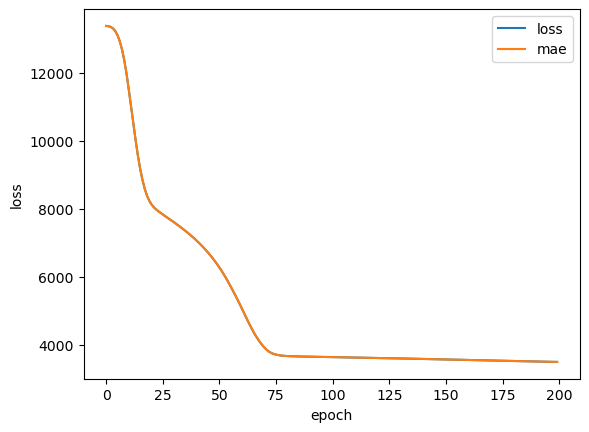

In [97]:
pd.DataFrame(history.history).plot()
plt.ylabel("loss")
plt.xlabel("epoch")
plt.legend()

### Preprocessing Data (Normalization and Standarization)

1. **Data Cleaning Techniques**

    Data cleaning focuses on removing noise, handling missing data, and fixing errors in your dataset.
    
    a. **Handling Missing Data**
    
    - **Removing Missing Data:**
    
        - Drop rows or columns with missing values if they are not critical (e.g., using df.dropna() in Pandas).
    
    - **Imputing Missing Data:**
    
        - **Mean/Median Imputation:** Replace missing values with the mean or median of the column.
        - **Mode Imputation:** Replace missing values with the mode (most frequent value) for categorical data.
        - **KNN Imputation:** Impute missing values using K-nearest neighbors.
        - **Model-Based Imputation:** Use machine learning models (e.g., linear regression or random forests) to predict missing values.
        - **Multiple Imputation:** Create several imputed datasets and combine the results.

    b. **Removing Duplicates**
    
    - **Drop Duplicates:** Duplicate rows can be dropped using df.drop_duplicates() in Pandas.
    
    c. **Handling Outliers**
    
    - **Z-Score:** Identify and remove outliers using Z-scores (values beyond a threshold like 3 standard deviations).
    - **IQR (Interquartile Range):** Remove values outside of 1.5 times the IQR above or below the quartiles.
    - **Winsorization:** Cap extreme values to a certain percentile (e.g., 1st and 99th percentiles).

2. **Feature Engineering Techniques**

    Feature engineering helps improve model performance by creating new variables or modifying existing ones.
    
    a. **Feature Creation**
    
    - **Interaction Features:** Create new features by combining existing ones (e.g., multiplying, adding, or dividing columns).
    - **Polynomial Features:** Generate higher-degree features to capture non-linear relationships.
    - **Domain-Specific Features:** Create features based on domain knowledge (e.g., extracting date parts like year, month, or day).
    
    b. **Feature Transformation**
    
    - **Log Transformation:** Apply a logarithmic transformation to reduce the impact of skewed data or highly skewed distributions (useful for data like income or price).
    - **Box-Cox / Yeo-Johnson:** Transform non-normal data to approximate normality.
    - **Power Transformation:** Apply mathematical functions (like square roots) to stabilize variance.
    
    c. **Categorical Encoding**
    
    - **One-Hot Encoding:** Convert categorical variables into binary vectors (as discussed earlier).
    - **Label Encoding:** Assign unique integer labels to categories (used for ordinal data).
    - **Frequency / Target Encoding:** Encode categorical features based on the frequency of their occurrence or target mean value.
    - **Binary Encoding:** A more efficient form of encoding for high-cardinality features.
    
    d. **Dimensionality Reduction**
    
    - **PCA (Principal Component Analysis):** Reduce the number of features by projecting data onto a lower-dimensional space.
    - **t-SNE / UMAP:** Use non-linear techniques to reduce dimensions while preserving structure (often for visualization).
    - **LDA (Linear Discriminant Analysis):** Reduce dimensions while maximizing class separability.

3. **Data Transformation Techniques**

    Data transformation ensures the dataset is in the correct scale and format for modeling.
    
    a. **Normalization and Scaling**
    
    - **Min-Max Scaling:** Scale the features to a fixed range, typically [0, 1], using MinMaxScaler.
    - **Standardization (Z-Score):** Scale the data so that it has a mean of 0 and a standard deviation of 1 using StandardScaler.
    - **Robust Scaling:** Use the median and interquartile range (IQR) for scaling, which is less sensitive to outliers.

    b. **Discretization**

    - **Binning:** Convert continuous data into discrete intervals (bins). For example, age groups like "18-25", "26-35", etc.
    - **Equal Width/Equal Frequency Binning:** Split the data into equal-width bins or bins with equal numbers of data points.

    c. **Encoding Date/Time Features**

    - **Extracting Date Components:** Convert datetime features into year, month, day, hour, minute, etc.
    - **Time Lag Features:** Create lag-based features for time series (e.g., previous day's price).
    - **Rolling Windows:** Compute rolling statistics (mean, sum, etc.) for time series data.

4. **Handling Text Data**

    Text data requires specific techniques to prepare it for machine learning models.

   a. **Text Preprocessing**

    - **Lowercasing:** Convert all text to lowercase to maintain uniformity.
    - **Removing Stopwords:** Eliminate common words like "the", "is", etc., that don't add meaningful information.
    - **Stemming and Lemmatization:** Reduce words to their base or root form (e.g., "running" to "run").
    - **Tokenization:** Split text into words or sub-words (tokens).
    - **Removing Punctuation and Special Characters:** Clean up non-alphanumeric characters.
    - **N-grams:** Use sequences of n-words (e.g., bigrams or trigrams) to capture context.

    b. **Text Vectorization**
    
    - **Bag of Words (BoW):** Convert text into a matrix where each row represents a document and each column represents a word in the vocabulary.
    - **TF-IDF (Term Frequency-Inverse Document Frequency):** Weigh words based on how frequently they appear in a document relative to how common they are across all documents.
    - **Word2Vec / GloVe:** Use pre-trained word embeddings to represent words in dense vector spaces, capturing semantic meaning.
    - **BERT Embeddings:** Use transformer-based embeddings for contextualized word representations.

5. **Feature Selection and Reduction**

    Selecting the most important features or reducing the number of features can help with model efficiency and performance.

   a. **Feature Selection Techniques**

    - **Filter Methods:** Use statistical tests (e.g., Chi-square, ANOVA) to identify relevant features.
    - **Wrapper Methods:** Use a machine learning model (e.g., recursive feature elimination or RFE) to iteratively remove features.
    - **Embedded Methods:** Use feature importance from models like decision trees, random forests, or Lasso regression.

    b. **Feature Importance**
    
    - **Random Forests:** Random Forests provide a feature importance ranking based on how much they improve the purity of the data splits.
    - **Lasso Regression:** Regularization in Lasso penalizes less important features, effectively selecting relevant features.

6. **Balancing Classes (for Imbalanced Datasets)**

    For classification tasks with imbalanced data (e.g., one class has significantly fewer samples than the other), balancing techniques are important.

    a. **Oversampling Techniques**
    
    - **SMOTE (Synthetic Minority Over-sampling Technique):** Generate synthetic examples for the minority class by interpolating between existing examples.
    - **Random Oversampling:** Randomly replicate examples from the minority class.

    b. **Undersampling Techniques**
    
    - **Random Undersampling:** Randomly reduce examples from the majority class.
    - **Cluster Centroids:** Undersample by using clustering techniques to create centroids for the majority class.

    c. **Class Weight Adjustments**
    
    - Adjust the weights of classes during model training (e.g., using class_weight in scikit-learn) to penalize misclassification of the minority class.
  
7. **Handling Imbalanced Time Series**

    For time series tasks, imbalanced classes can still be an issue. Techniques like resampling and forecasting can help address the imbalance over time.